# 🏦 Анализ данных Lending Club: от чего зависит дефолт по кредиту

**Курс:** Python for Data Science (DSBA), 2025/2026 — итоговый проект
**Датасет:** [Lending Club Loan Data](https://www.kaggle.com/datasets/adarshsng/lending-club-loan-data-csv) (Kaggle)

> **Автор проекта:** _укажи свои ФИО и группу_ — отредактируй эту строку перед сдачей.

---

## Аннотация

Lending Club — крупнейшая в США платформа однорангового (P2P) кредитования: люди берут
потребительские займы, а инвесторы их финансируют. Для инвестора главный вопрос — **вернут
ли деньги**. В этой работе на 396 тысячах выданных кредитов мы исследуем, какие характеристики
заёмщика и самого займа связаны с его исходом (полное погашение или дефолт — *Charged Off*).
Мы проводим полный цикл анализа: описываем данные и их качество, считаем описательную статистику,
чистим данные, строим разведочные и сравнительные графики, конструируем новые признаки и,
наконец, формулируем и статистически проверяем содержательные гипотезы о факторах риска.

Главный сюжет работы — насколько **грейд** (буквенный рейтинг надёжности A–G, который платформа
присваивает кредиту) и **процентная ставка** отражают реальный риск, и сохраняется ли влияние
срока и ставки на дефолт *при прочих равных*. **Распределение вклада:** проект выполнен одним
автором — сбор и предобработка данных, разведочный анализ, визуализация, проверка гипотез и
оформление отчёта (если работа командная — перечисли участников и кто что делал в этой строке).

## 1. Импорты и настройка оформления

Подключаем стандартный стек: `numpy`/`pandas` для данных, `matplotlib`/`seaborn` для графиков,
`scipy.stats` — для статистических тестов в разделе про гипотезы.

In [1]:
import warnings
warnings.filterwarnings("ignore")          # глушим технические предупреждения версий

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats                     # стат-тесты для проверки гипотез

# единый стиль графиков
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"]   = (9, 5)
plt.rcParams["axes.titlesize"]   = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"]       = 110
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Окружение готово. pandas", pd.__version__, "| numpy", np.__version__)

Окружение готово. pandas 3.0.3 | numpy 1.26.4


## 2. Описание датасета

**Предметная область:** потребительское кредитование (финтех, P2P-займы). Каждая строка — это
один выданный кредит: его параметры (сумма, ставка, срок, грейд), данные о заёмщике (доход,
стаж, тип жилья, долговая нагрузка) и **итог** — погашен кредит или ушёл в дефолт.

Датасет — это **одна таблица** из 27 полей: смесь числовых (`loan_amnt`, `int_rate`, `annual_inc`,
`dti` …), категориальных (`grade`, `home_ownership`, `purpose` …), текстовых (`emp_title`,
`address`) и «дат-как-текст» (`issue_d`, `earliest_cr_line`). Загрузим и посмотрим.

In [2]:
df = pd.read_csv("data/lending_club_loan.csv")
print(f"Строк: {df.shape[0]:,}   Колонок: {df.shape[1]}")
df.head()

Строк: 396,030   Колонок: 27


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,"10,000.00",36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,"117,000.00",Not Verified,Jan-2015,Fully Paid,vacation,Vacation,26.24,Jun-1990,16.00,0.00,"36,369.00",41.80,25.00,w,INDIVIDUAL,0.00,0.00,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,"8,000.00",36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,"65,000.00",Not Verified,Jan-2015,Fully Paid,debt_consolidation,Debt consolidation,22.05,Jul-2004,17.00,0.00,"20,131.00",53.30,27.00,f,INDIVIDUAL,3.00,0.00,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,"15,600.00",36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,"43,057.00",Source Verified,Jan-2015,Fully Paid,credit_card,Credit card refinancing,12.79,Aug-2007,13.00,0.00,"11,987.00",92.20,26.00,f,INDIVIDUAL,0.00,0.00,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,"7,200.00",36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,"54,000.00",Not Verified,Nov-2014,Fully Paid,credit_card,Credit card refinancing,2.60,Sep-2006,6.00,0.00,"5,472.00",21.50,13.00,f,INDIVIDUAL,0.00,0.00,"823 Reid Ford\nDelacruzside, MA 00813"
4,"24,375.00",60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,"55,000.00",Verified,Apr-2013,Charged Off,credit_card,Credit Card Refinance,33.95,Mar-1999,13.00,0.00,"24,584.00",69.80,43.00,f,INDIVIDUAL,1.00,0.00,"679 Luna Roads\nGreggshire, VA 11650"


### Словарь полей

| Поле | Что означает |
|------|--------------|
| `loan_amnt` | сумма выданного кредита, $ |
| `term` | срок кредита (текст: « 36 months» / « 60 months») |
| `int_rate` | годовая процентная ставка, % |
| `installment` | ежемесячный платёж, $ |
| `grade` / `sub_grade` | буквенный грейд надёжности A–G и под-грейд A1–G5 |
| `emp_title` / `emp_length` | должность и стаж работы заёмщика |
| `home_ownership` | тип жилья (RENT / MORTGAGE / OWN …) |
| `annual_inc` | годовой доход заёмщика, $ |
| `verification_status` | проверялся ли доход платформой |
| `issue_d` | месяц выдачи кредита |
| `loan_status` | **итог: Fully Paid (погашен) / Charged Off (дефолт)** |
| `purpose` / `title` | цель кредита |
| `dti` | debt-to-income: отношение платежей по долгам к доходу, % |
| `earliest_cr_line` | дата открытия первой кредитной линии |
| `open_acc` / `total_acc` | число открытых / всего кредитных счетов |
| `pub_rec` / `pub_rec_bankruptcies` | публичные записи / банкротства |
| `revol_bal` / `revol_util` | револьверный баланс, $ / использование лимита, % |
| `initial_list_status` | статус листинга (w / f) |
| `application_type` | тип заявки (INDIVIDUAL / JOINT …) |
| `mort_acc` | число ипотечных счетов |
| `address` | адрес заёмщика (из него вытащим штат) |

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  str    
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  str    
 5   sub_grade             396030 non-null  str    
 6   emp_title             373103 non-null  str    
 7   emp_length            377729 non-null  str    
 8   home_ownership        396030 non-null  str    
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  str    
 11  issue_d               396030 non-null  str    
 12  loan_status           396030 non-null  str    
 13  purpose               396030 non-null  str    
 14  title                 394274 non-null  str    
 15  dti        

### Качество данных

Проверяем три типичные проблемы: **пропуски**, **некорректные типы** и **аномальные значения**.

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"Пропусков": missing, "Доля, %": missing_pct})

,Пропусков,"Доля, %"
mort_acc,37795,9.54
emp_title,22927,5.79
emp_length,18301,4.62
title,1756,0.44
pub_rec_bankruptcies,535,0.14
revol_util,276,0.07


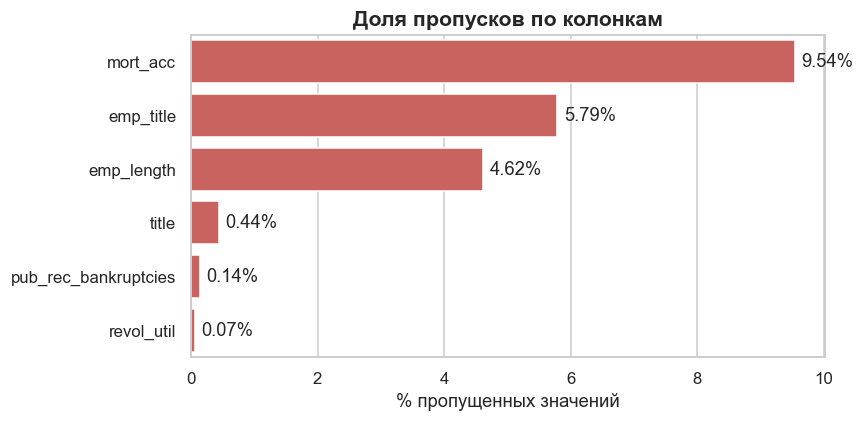

In [5]:
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="#d9534f")
plt.title("Доля пропусков по колонкам")
plt.xlabel("% пропущенных значений"); plt.ylabel("")
for i, v in enumerate(missing_pct.values):
    plt.text(v + 0.1, i, f"{v}%", va="center")
plt.tight_layout(); plt.show()

In [6]:
# Некорректные типы и аномалии
print("1) Тип хранится как текст, хотя по смыслу это число:")
print("   term       :", df["term"].dropna().unique())
print("   emp_length :", df["emp_length"].dropna().unique()[:4], "...")
print()
print("2) Явные выбросы / заглушки:")
print(f"   dti == 9999 (заглушка):     {(df['dti'] >= 9999).sum()} строк")
print(f"   dti > 60 (нереальная нагрузка): {(df['dti'] > 60).sum()} строк")
print(f"   макс. годовой доход:        {df['annual_inc'].max():,.0f} $ (хвост в миллионы)")
print(f"   revol_util > 100%:          {(df['revol_util'] > 100).sum()} строк")
print()
print("3) Целевая переменная сбалансирована умеренно:")
print(df["loan_status"].value_counts())
print(f"   доля дефолтов: {(df['loan_status']=='Charged Off').mean()*100:.1f}%")

1) Тип хранится как текст, хотя по смыслу это число:
   term       : <StringArray>
[' 36 months', ' 60 months']
Length: 2, dtype: str
   emp_length : <StringArray>
['10+ years', '4 years', '< 1 year', '6 years']
Length: 4, dtype: str ...

2) Явные выбросы / заглушки:
   dti == 9999 (заглушка):     1 строк
   dti > 60 (нереальная нагрузка): 19 строк
   макс. годовой доход:        8,706,582 $ (хвост в миллионы)
   revol_util > 100%:          1167 строк

3) Целевая переменная сбалансирована умеренно:
loan_status
Fully Paid     318357
Charged Off     77673
Name: count, dtype: int64
   доля дефолтов: 19.6%


**Вывод по качеству.** Данные в целом аккуратные, но требуют обработки:
пропуски сосредоточены в нескольких колонках (`mort_acc` ~9.5%, `emp_length`, `emp_title`,
`title`, `pub_rec_bankruptcies`, `revol_util`); поля `term` и `emp_length` хранятся как текст,
хотя несут числовой смысл; в `dti` есть заглушка `9999`, а у `annual_inc` — тяжёлый правый хвост.
Всё это поправим в разделе очистки.

## 3. Описательная статистика числовых полей

Считаем сводную статистику для основных числовых признаков. Для каждого приводим как минимум
**среднее (mean)**, **медиану (median)** и **стандартное отклонение (std)** — а также квартили
и диапазон, чтобы увидеть форму распределения и наличие хвостов.

In [7]:
num_fields = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "revol_util"]

desc = df[num_fields].describe().T
desc["median"] = df[num_fields].median()
desc = desc[["count", "mean", "median", "std", "min", "25%", "75%", "max"]]
desc.round(2)

,count,mean,median,std,min,25%,75%,max
loan_amnt,"396,030.00","14,113.89","12,000.00","8,357.44",500.00,"8,000.00","20,000.00","40,000.00"
int_rate,"396,030.00",13.64,13.33,4.47,5.32,10.49,16.49,30.99
installment,"396,030.00",431.85,375.43,250.73,16.08,250.33,567.30,"1,533.81"
annual_inc,"396,030.00","74,203.18","64,000.00","61,637.62",0.00,"45,000.00","90,000.00","8,706,582.00"
dti,"396,030.00",17.38,16.91,18.02,0.00,11.28,22.98,"9,999.00"
revol_util,"395,754.00",53.79,54.80,24.45,0.00,35.80,72.90,892.30


In [8]:
# Те же mean / median / std крупным планом — по требованию (≥4 числовых поля)
print("Ключевые описательные статистики:\n")
for col in num_fields:
    s = df[col].dropna()
    print(f"{col:12} | mean = {s.mean():12,.2f} | median = {s.median():12,.2f} "
          f"| std = {s.std():12,.2f}")

Ключевые описательные статистики:

loan_amnt    | mean =    14,113.89 | median =    12,000.00 | std =     8,357.44
int_rate     | mean =        13.64 | median =        13.33 | std =         4.47
installment  | mean =       431.85 | median =       375.43 | std =       250.73
annual_inc   | mean =    74,203.18 | median =    64,000.00 | std =    61,637.62
dti          | mean =        17.38 | median =        16.91 | std =        18.02
revol_util   | mean =        53.79 | median =        54.80 | std =        24.45


**Что видно из статистики.** Типичный кредит — около \$14k (медиана \$12k) под ~13–14% годовых
с платежом ~\$430/мес. Распределение дохода сильно скошено: среднее (\$74k) заметно выше медианы
(\$64k) из-за богатого хвоста. У `dti` среднее (17.4) близко к медиане (16.9), но огромный `std`
(18) выдаёт выбросы-заглушки `9999`, которые мы уберём при очистке. `revol_util` (использование
кредитного лимита) в среднем ~54% — заёмщики используют примерно половину доступного лимита.

## 4. Очистка данных

План: (1) превратить текстовые поля в числа и вытащить штат из адреса; (2) ввести целевую
переменную `is_default`; (3) заполнить пропуски там, где это осмысленно, и удалить остаточные
строки с пропусками; (4) убрать явные аномалии (`dti`-заглушки, нулевой доход); (5) выкинуть
свободный текст, который не пригодится. Работаем с копией — исходный `df` остаётся нетронутым.

In [9]:
data = df.copy()

# 4.1 term: " 36 months" -> 36 (int)
data["term_months"] = data["term"].str.extract(r"(\d+)").astype(int)

# 4.2 emp_length: текст -> упорядоченное число лет
emp_map = {"< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
           "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
           "10+ years": 10}
data["emp_length_num"] = data["emp_length"].str.strip().map(emp_map)
data["emp_length_num"] = data["emp_length_num"].fillna(data["emp_length_num"].median())

# 4.3 штат из адреса (2 буквы перед 5-значным индексом)
data["state"] = data["address"].str.extract(r"([A-Z]{2})\s+\d{5}\s*$")

# 4.4 целевая переменная: 1 = дефолт (Charged Off), 0 = погашен
data["is_default"] = (data["loan_status"] == "Charged Off").astype(int)

print("Добавлены служебные колонки: term_months, emp_length_num, state, is_default")
data[["term", "term_months", "emp_length", "emp_length_num",
      "loan_status", "is_default"]].head()

Добавлены служебные колонки: term_months, emp_length_num, state, is_default


,term,term_months,emp_length,emp_length_num,loan_status,is_default
0,36 months,36,10+ years,10.00,Fully Paid,0
1,36 months,36,4 years,4.00,Fully Paid,0
2,36 months,36,< 1 year,0.00,Fully Paid,0
3,36 months,36,6 years,6.00,Fully Paid,0
4,60 months,60,9 years,9.00,Charged Off,1


In [10]:
# 4.5 заполняем пропуски в числовых колонках осмысленными значениями
data["mort_acc"]            = data["mort_acc"].fillna(data["mort_acc"].median())
data["revol_util"]          = data["revol_util"].fillna(data["revol_util"].median())
data["pub_rec_bankruptcies"] = data["pub_rec_bankruptcies"].fillna(0)

# 4.6 выкидываем свободный текст (десятки тысяч уникальных значений) и дубли полей
drop_cols = ["emp_title", "title", "address", "term", "emp_length"]
data = data.drop(columns=drop_cols)

# 4.7 удаляем оставшиеся строки с пропусками (требование: rows with NaN)
before = len(data)
data = data.dropna().reset_index(drop=True)
print(f"Удалили колонки: {drop_cols}")
print(f"Удалили строк с остаточными пропусками: {before - len(data)}")
print(f"Пропусков осталось всего: {int(data.isna().sum().sum())}")

Удалили колонки: ['emp_title', 'title', 'address', 'term', 'emp_length']
Удалили строк с остаточными пропусками: 0
Пропусков осталось всего: 0


In [11]:
# 4.8 чистим аномалии: заглушки в dti и нулевой/отрицательный доход
before = len(data)
data = data[(data["dti"] <= 60) & (data["annual_inc"] > 0)].copy()
removed = before - len(data)
print(f"Удалили {removed} строк с аномалиями (dti>60 или доход<=0) "
      f"— {removed/before*100:.2f}% данных")
print(f"\nИтоговый размер: {data.shape[0]:,} строк × {data.shape[1]} колонок")
print("\nПроверка типов после очистки:")
print(data.dtypes.value_counts())

Удалили 19 строк с аномалиями (dti>60 или доход<=0) — 0.00% данных

Итоговый размер: 396,011 строк × 26 колонок

Проверка типов после очистки:
float64    13
str        11
int64       2
Name: count, dtype: int64


**Итог очистки.** Текстовые `term`/`emp_length` стали числами, из адреса извлечён штат, введена
бинарная цель `is_default`. Пропуски в `mort_acc`/`revol_util`/`pub_rec_bankruptcies` заполнены,
остаточные строки с пропусками и явные аномалии (`dti`-заглушки `9999`, нулевой доход) удалены —
суммарно потеряли менее процента данных. Дальше работаем с чистым `data`.

## 5. Графики числовых полей

Чтобы понять форму данных, строим графики для пяти числовых полей —
`loan_amnt`, `annual_inc`, `int_rate`, `installment`, `dti` — используя **три разных типа**:
гистограмму, ящик с усами (boxplot) и диаграмму рассеяния (scatter).

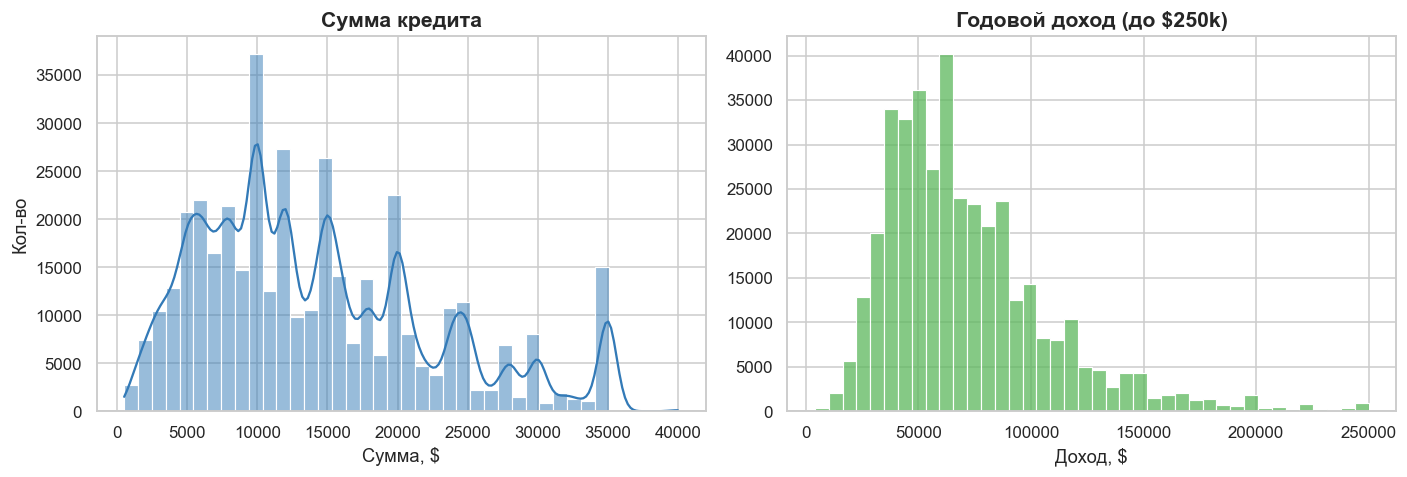

In [12]:
# Тип 1 — ГИСТОГРАММЫ: распределение суммы кредита и годового дохода
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data["loan_amnt"], bins=40, kde=True, color="#337ab7", ax=axes[0])
axes[0].set_title("Сумма кредита"); axes[0].set_xlabel("Сумма, $"); axes[0].set_ylabel("Кол-во")

sns.histplot(data[data["annual_inc"] <= 250_000]["annual_inc"], bins=40,
             color="#5cb85c", ax=axes[1])
axes[1].set_title("Годовой доход (до $250k)"); axes[1].set_xlabel("Доход, $"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

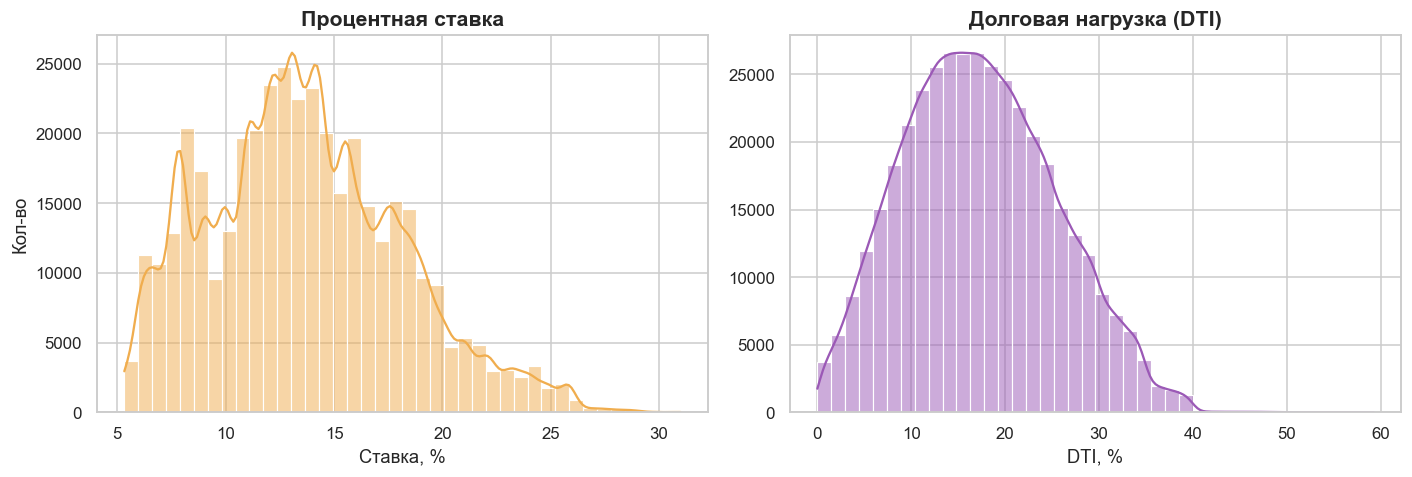

In [13]:
# Тип 1 (ещё) — гистограммы ставки и долговой нагрузки
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data["int_rate"], bins=40, kde=True, color="#f0ad4e", ax=axes[0])
axes[0].set_title("Процентная ставка"); axes[0].set_xlabel("Ставка, %"); axes[0].set_ylabel("Кол-во")

sns.histplot(data["dti"], bins=40, kde=True, color="#9b59b6", ax=axes[1])
axes[1].set_title("Долговая нагрузка (DTI)"); axes[1].set_xlabel("DTI, %"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

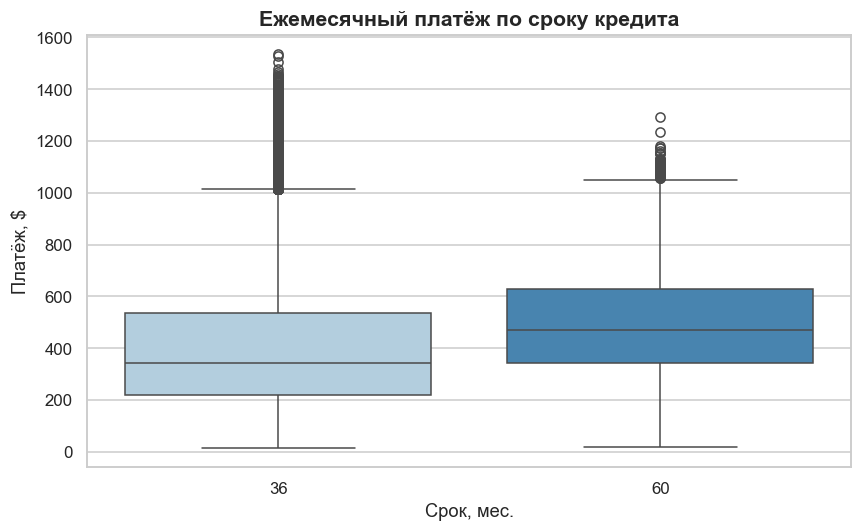

In [14]:
# Тип 2 — BOXPLOT: ежемесячный платёж по сроку кредита
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="term_months", y="installment", palette="Blues")
plt.title("Ежемесячный платёж по сроку кредита")
plt.xlabel("Срок, мес."); plt.ylabel("Платёж, $")
plt.tight_layout(); plt.show()

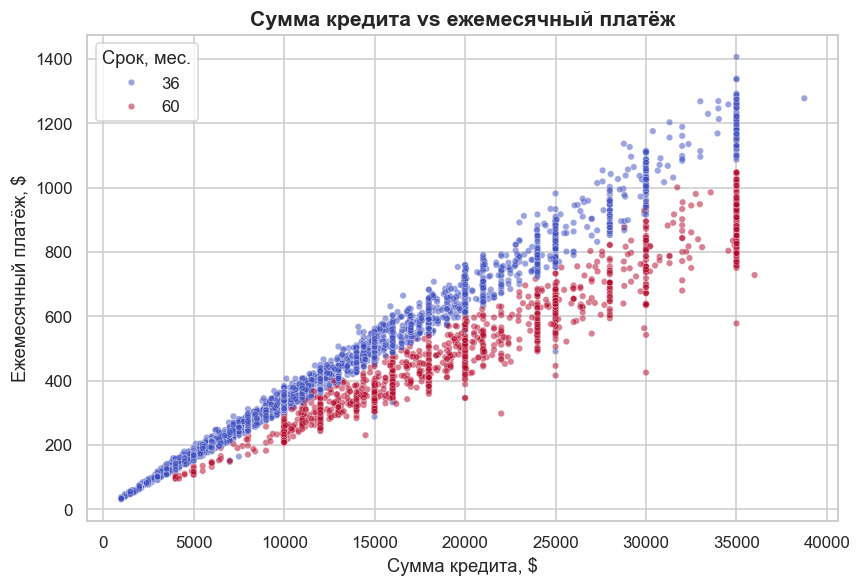

In [15]:
# Тип 3 — SCATTER: сумма кредита vs ежемесячный платёж (ожидаем сильную линейную связь)
sample = data.sample(5000, random_state=1)
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=sample, x="loan_amnt", y="installment",
                hue="term_months", palette="coolwarm", alpha=0.5, s=18)
plt.title("Сумма кредита vs ежемесячный платёж")
plt.xlabel("Сумма кредита, $"); plt.ylabel("Ежемесячный платёж, $")
plt.legend(title="Срок, мес.")
plt.tight_layout(); plt.show()

**Обсуждение.** Сумма кредита распределена с «горбами» на круглых значениях (10k, 15k, 20k),
доход — резко скошен вправо. Ставка похожа на смесь нескольких пиков (по грейдам). На scatter
видно почти прямую линию «сумма → платёж», причём она расщепляется на два луча: при сроке 60
месяцев тот же кредит даёт меньший ежемесячный платёж, чем при 36 — что логично. Итого покрыто
**5 числовых полей** тремя типами графиков.

## 6. Детальный обзор: сравнения и связи

Теперь — самое интересное: сравнения по условиям и поиск зависимостей. Здесь несколько графиков
с разбиением по категориям, цвет как третья ось, сводные таблицы и временной ряд.

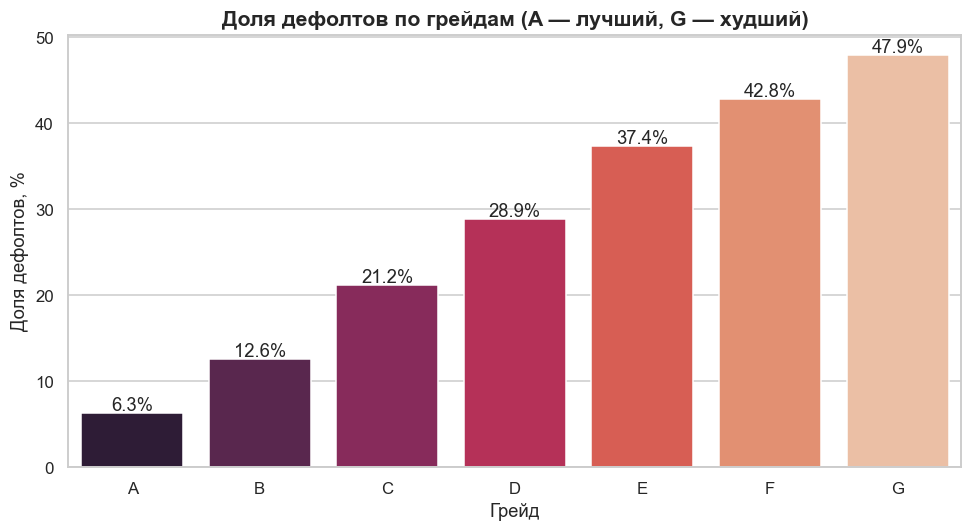

grade
A    6.30
B   12.60
C   21.20
D   28.90
E   37.40
F   42.80
G   47.90
Name: is_default, dtype: float64

In [16]:
# 6.1 Доля дефолтов по грейдам — ключевой график
default_by_grade = (data.groupby("grade")["is_default"].mean() * 100).round(1)
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=default_by_grade.index, y=default_by_grade.values, palette="rocket")
plt.title("Доля дефолтов по грейдам (A — лучший, G — худший)")
plt.xlabel("Грейд"); plt.ylabel("Доля дефолтов, %")
for i, v in enumerate(default_by_grade.values):
    ax.text(i, v + 0.3, f"{v}%", ha="center")
plt.tight_layout(); plt.show()
default_by_grade

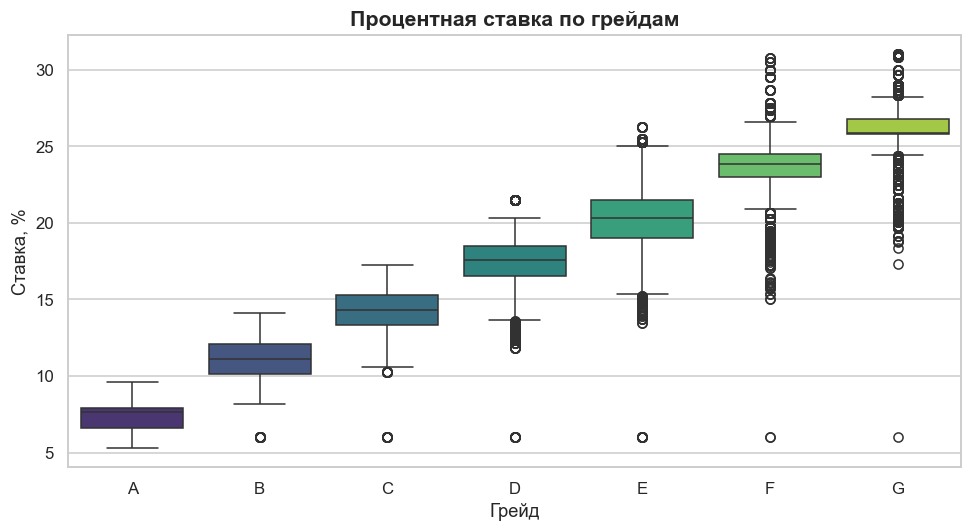

In [17]:
# 6.2 Ставка по грейдам (boxplot) — связь грейда и цены кредита
plt.figure(figsize=(9, 5))
sns.boxplot(data=data, x="grade", y="int_rate",
            order=sorted(data["grade"].unique()), palette="viridis")
plt.title("Процентная ставка по грейдам")
plt.xlabel("Грейд"); plt.ylabel("Ставка, %")
plt.tight_layout(); plt.show()

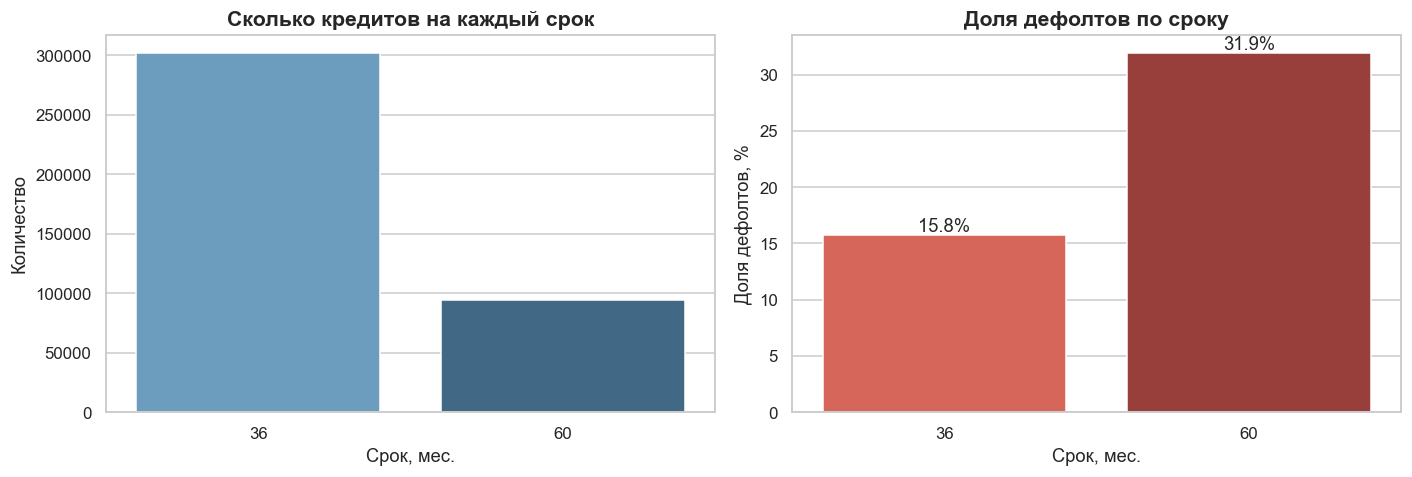

In [18]:
# 6.3 Срок кредита: количество и доля дефолтов рядом (два графика для сравнения)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=data, x="term_months", palette="Blues_d", ax=axes[0])
axes[0].set_title("Сколько кредитов на каждый срок")
axes[0].set_xlabel("Срок, мес."); axes[0].set_ylabel("Количество")

dr = data.groupby("term_months")["is_default"].mean() * 100
sns.barplot(x=dr.index, y=dr.values, palette="Reds_d", ax=axes[1])
axes[1].set_title("Доля дефолтов по сроку")
axes[1].set_xlabel("Срок, мес."); axes[1].set_ylabel("Доля дефолтов, %")
for i, v in enumerate(dr.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center")
plt.tight_layout(); plt.show()

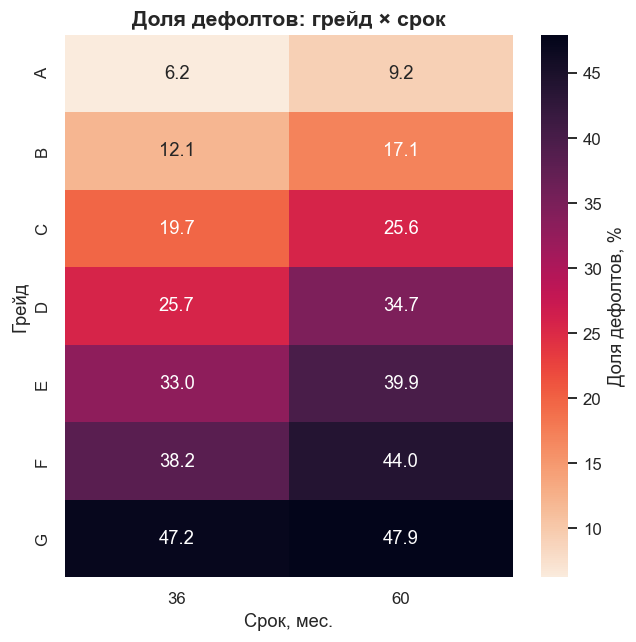

In [19]:
# 6.4 Тепловая карта: доля дефолтов в разрезе грейд × срок (третья ось — цвет)
pivot = data.pivot_table(index="grade", columns="term_months",
                         values="is_default", aggfunc="mean") * 100
plt.figure(figsize=(6, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="rocket_r",
            cbar_kws={"label": "Доля дефолтов, %"})
plt.title("Доля дефолтов: грейд × срок")
plt.xlabel("Срок, мес."); plt.ylabel("Грейд")
plt.tight_layout(); plt.show()

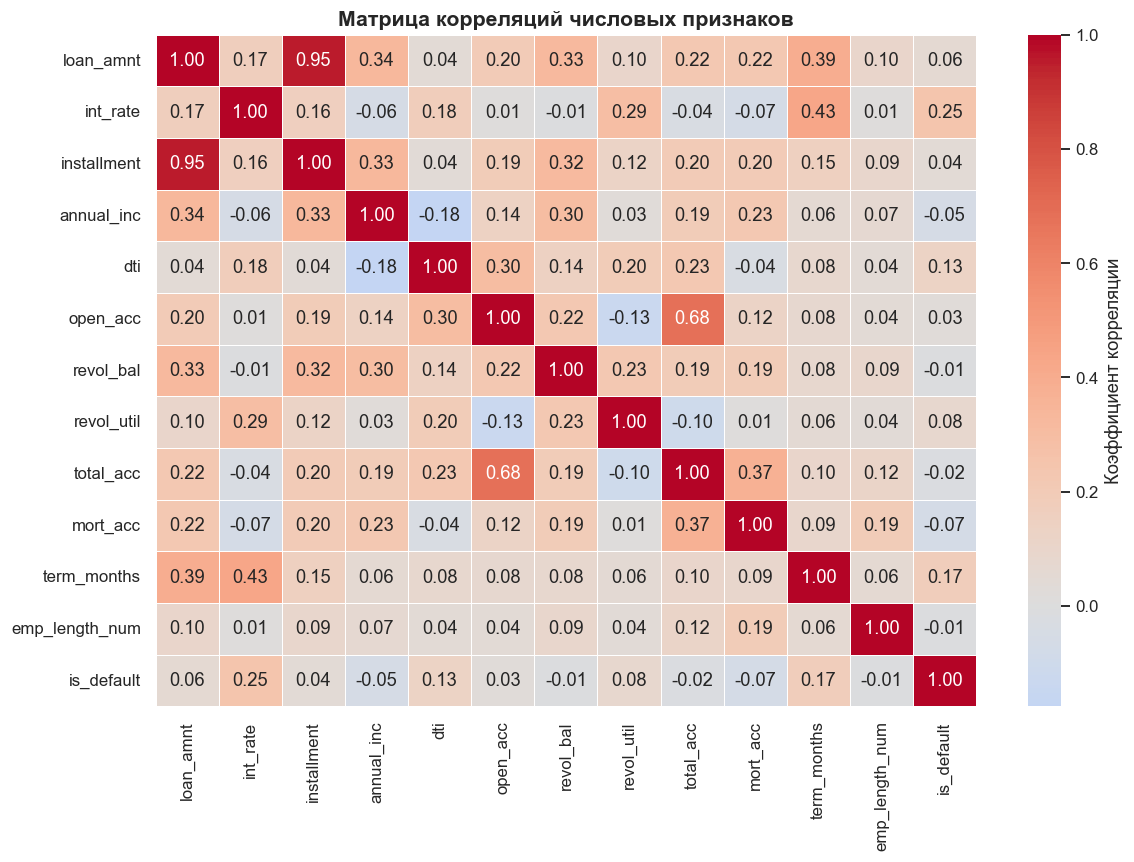

In [20]:
# 6.5 Матрица корреляций числовых признаков
num_cols = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti",
            "open_acc", "revol_bal", "revol_util", "total_acc",
            "mort_acc", "term_months", "emp_length_num", "is_default"]
corr = data[num_cols].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Коэффициент корреляции"})
plt.title("Матрица корреляций числовых признаков")
plt.tight_layout(); plt.show()

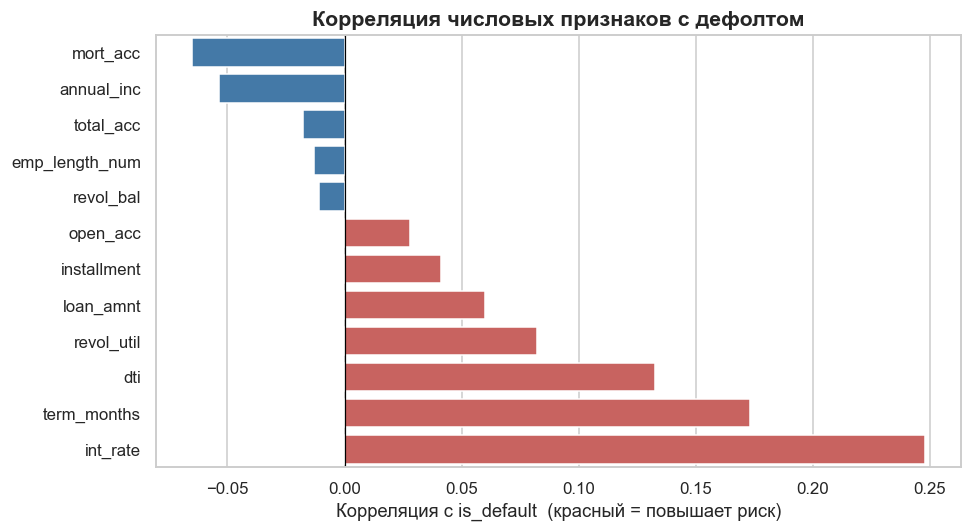

In [21]:
# 6.6 Что сильнее всего связано с дефолтом
corr_target = corr["is_default"].drop("is_default").sort_values()
colors = ["#d9534f" if v > 0 else "#337ab7" for v in corr_target.values]
plt.figure(figsize=(9, 5))
sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors)
plt.title("Корреляция числовых признаков с дефолтом")
plt.xlabel("Корреляция с is_default  (красный = повышает риск)"); plt.ylabel("")
plt.axvline(0, color="black", lw=0.8)
plt.tight_layout(); plt.show()

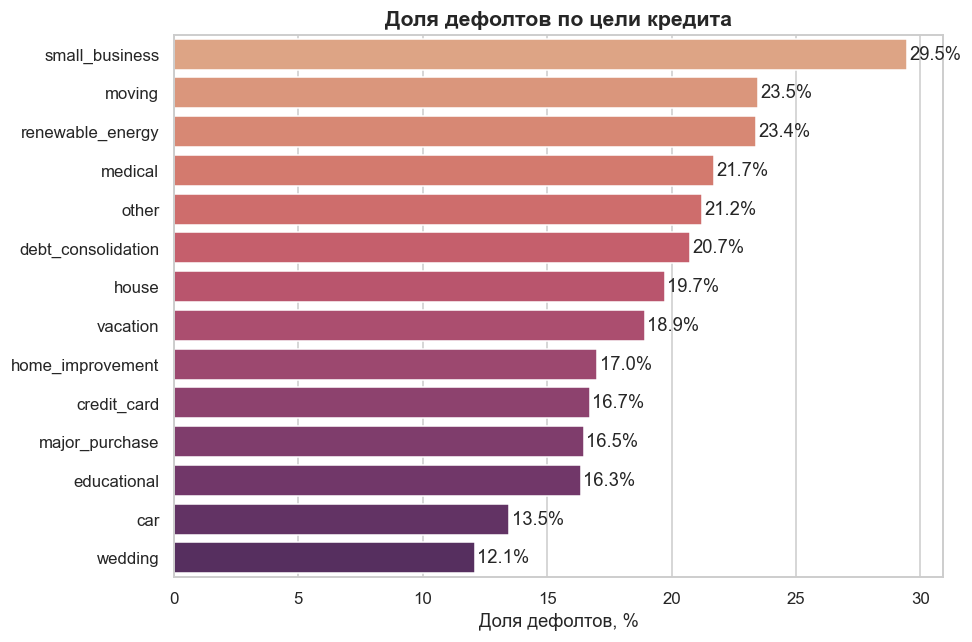

In [22]:
# 6.7 Доля дефолтов по цели кредита (сравнение категорий)
dr = (data.groupby("purpose")["is_default"].mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(9, 6))
ax = sns.barplot(x=dr.values, y=dr.index, palette="flare")
plt.title("Доля дефолтов по цели кредита")
plt.xlabel("Доля дефолтов, %"); plt.ylabel("")
for i, v in enumerate(dr.values):
    ax.text(v + 0.1, i, f"{v:.1f}%", va="center")
plt.tight_layout(); plt.show()

In [23]:
# 6.8 Сводная статистика по грейдам (печать статистики для подмножеств)
summary = data.groupby("grade").agg(
    кол_во=("grade", "size"),
    ставка=("int_rate", "mean"),
    сумма=("loan_amnt", "mean"),
    доход=("annual_inc", "mean"),
    DTI=("dti", "mean"),
    исп_лимита=("revol_util", "mean"),
    доля_дефолтов=("is_default", "mean"),
).round(2)
summary["доля_дефолтов"] = (summary["доля_дефолтов"] * 100).round(1)
summary

,кол_во,ставка,сумма,доход,DTI,исп_лимита,доля_дефолтов
grade,,,,,,,
A,64186,7.39,"13,294.86","84,704.69",14.72,38.64,6.00
B,116012,11.22,"12,895.47","73,525.84",16.63,52.53,13.00
C,105982,14.32,"13,760.98","71,226.76",17.94,57.27,21.00
D,63521,17.48,"14,695.31","69,684.07",18.77,60.08,29.00
E,31487,20.28,"17,723.57","73,553.07",19.48,61.08,37.00
F,11770,23.70,"19,210.16","75,018.48",19.47,62.11,43.00
G,3053,25.90,"20,885.74","80,425.33",19.22,61.78,48.00


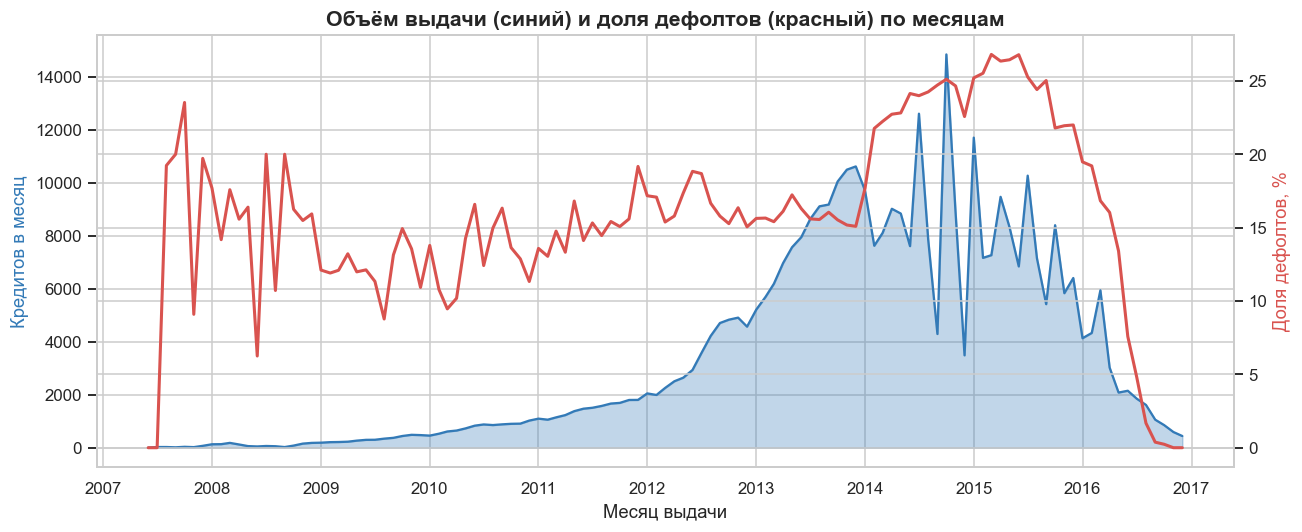

In [24]:
# 6.9 Временной ряд: объём выдачи и доля дефолтов по месяцам (две линии/оси)
data["issue_date"] = pd.to_datetime(data["issue_d"], format="%b-%Y")
monthly = data.groupby(data["issue_date"].dt.to_period("M")).agg(
    n=("is_default", "size"), default_rate=("is_default", "mean"))
monthly.index = monthly.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.fill_between(monthly.index, monthly["n"], color="#337ab7", alpha=0.3)
ax1.plot(monthly.index, monthly["n"], color="#337ab7")
ax1.set_ylabel("Кредитов в месяц", color="#337ab7"); ax1.set_xlabel("Месяц выдачи")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["default_rate"] * 100, color="#d9534f", lw=2)
ax2.set_ylabel("Доля дефолтов, %", color="#d9534f")
plt.title("Объём выдачи (синий) и доля дефолтов (красный) по месяцам")
fig.tight_layout(); plt.show()

**Обсуждение.** Грейд работает как настоящая мера риска: дефолты растут почти монотонно от A
(~5–7%) к G (~35–40%), и ставка по грейдам растёт так же — платформа закладывает риск в цену.
Длинные кредиты (60 мес.) дефолтят почти вдвое чаще коротких, а тепловая карта показывает, что
худший сценарий — плохой грейд *и* длинный срок одновременно. По корреляциям сильнее всего риск
повышают ставка и срок, а снижают — наличие ипотечных счетов. Среди целей самые рискованные —
кредиты на малый бизнес. Объёмы выдачи росли год от года.

## 7. Трансформация данных: новые признаки

Сконструируем новые колонки из имеющихся — они пригодятся для проверки гипотез:

- **`grade_num`** — грейд A–G как число 1–7 (порядковое кодирование);
- **`total_payment`** = `installment` × `term_months` — сколько всего заёмщик вернёт;
- **`total_interest`** = `total_payment` − `loan_amnt` — переплата в долларах;
- **`overpay_ratio`** = `total_interest` / `loan_amnt` — переплата в долях от тела кредита;
- **`payment_to_income`** = `installment` × 12 / `annual_inc` — годовая платёжная нагрузка к доходу;
- **`credit_history_years`** — длина кредитной истории на момент выдачи (лет).

In [25]:
grade_order = sorted(data["grade"].unique())              # ['A', ..., 'G']
grade_to_num = {g: i + 1 for i, g in enumerate(grade_order)}
data["grade_num"] = data["grade"].map(grade_to_num)

data["total_payment"]     = data["installment"] * data["term_months"]
data["total_interest"]    = data["total_payment"] - data["loan_amnt"]
data["overpay_ratio"]     = data["total_interest"] / data["loan_amnt"]
data["payment_to_income"] = data["installment"] * 12 / data["annual_inc"]

earliest = pd.to_datetime(data["earliest_cr_line"], format="%b-%Y")
data["credit_history_years"] = ((data["issue_date"] - earliest).dt.days / 365.25).round(1)

print("Кодировка грейда:", grade_to_num, "\n")
data[["grade", "grade_num", "loan_amnt", "total_payment", "total_interest",
      "overpay_ratio", "payment_to_income", "credit_history_years"]].head()

Кодировка грейда: {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7} 



,grade,grade_num,loan_amnt,total_payment,total_interest,overpay_ratio,payment_to_income,credit_history_years
0,B,2,"10,000.00","11,861.28","1,861.28",0.19,0.03,24.60
1,B,2,"8,000.00","9,564.48","1,564.48",0.20,0.05,10.50
2,B,2,"15,600.00","18,250.92","2,650.92",0.17,0.14,7.40
3,A,1,"7,200.00","7,943.40",743.40,0.10,0.05,8.20
4,C,3,"24,375.00","36,559.80","12,184.80",0.50,0.13,14.10


In [26]:
# краткая статистика новых признаков
data[["overpay_ratio", "payment_to_income", "credit_history_years",
      "total_interest"]].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
overpay_ratio,"396,011.00",0.27,0.16,-0.89,0.17,0.23,0.32,0.98
payment_to_income,"396,011.00",0.08,0.04,0.00,0.05,0.07,0.11,0.48
credit_history_years,"396,011.00",15.75,7.20,3.00,10.90,14.30,19.30,70.20
total_interest,"396,011.00","4,286.01","4,451.17","-19,406.68","1,443.80","2,583.80","5,467.88","37,634.00"


**Обсуждение.** Переплата (`overpay_ratio`) в среднем составляет существенную долю тела кредита и
сильно зависит от срока и ставки. `payment_to_income` показывает, какую часть годового дохода
съедают платежи. `credit_history_years` варьируется от пары лет до нескольких десятилетий. Эти
признаки используем для гипотез ниже.

## 8. Проверка гипотез

Сформулируем содержательные гипотезы — сложнее простого сравнения двух подвыборок по одной
колонке — и проверим их **графиком и статистическим тестом** (`scipy.stats`). Уровень значимости
α = 0.05.

### Гипотеза 1. Длинный срок повышает риск дефолта *при одинаковом грейде*

Мы уже видели, что 60-месячные кредиты дефолтят чаще. Но 60 мес. чаще дают «плохим» грейдам —
может, дело только в грейде? Проверим влияние срока **внутри каждого грейда** (контролируем
грейд). Тест: χ² на независимость `срок × дефолт` отдельно в каждом грейде.

In [27]:
rows = []
for g in grade_order:
    sub = data[data["grade"] == g]
    ct = pd.crosstab(sub["term_months"], sub["is_default"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    dr36 = sub[sub["term_months"] == 36]["is_default"].mean() * 100
    dr60 = sub[sub["term_months"] == 60]["is_default"].mean() * 100
    rows.append([g, round(dr36, 1), round(dr60, 1), round(dr60 - dr36, 1), p])

h1 = pd.DataFrame(rows, columns=["грейд", "дефолт_36мес_%", "дефолт_60мес_%",
                                 "разница_пп", "p_value"])
print(h1.to_string(index=False))
print("\nВ каждом грейде 60 мес. дефолтит чаще:",
      bool((h1["разница_пп"] > 0).all()))
print("Везде статистически значимо (p<0.05):",
      bool((h1["p_value"] < 0.05).all()))

грейд  дефолт_36мес_%  дефолт_60мес_%  разница_пп  p_value
    A            6.20            9.20        3.00     0.00
    B           12.10           17.10        5.10     0.00
    C           19.70           25.60        6.00     0.00
    D           25.70           34.70        9.00     0.00
    E           33.00           39.90        6.80     0.00
    F           38.20           44.00        5.80     0.00
    G           47.20           47.90        0.80     0.83

В каждом грейде 60 мес. дефолтит чаще: True
Везде статистически значимо (p<0.05): False


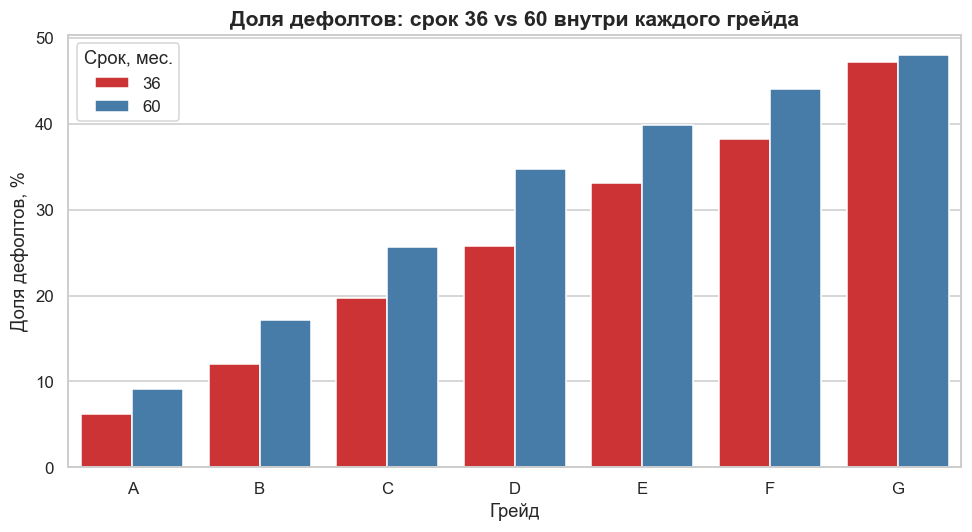

In [28]:
# визуализация H1: доля дефолтов 36 vs 60 внутри каждого грейда
plot_df = data.groupby(["grade", "term_months"])["is_default"].mean().mul(100).reset_index()
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="grade", y="is_default", hue="term_months", palette="Set1")
plt.title("Доля дефолтов: срок 36 vs 60 внутри каждого грейда")
plt.xlabel("Грейд"); plt.ylabel("Доля дефолтов, %"); plt.legend(title="Срок, мес.")
plt.tight_layout(); plt.show()

**Вывод по H1.** Гипотеза **подтвердилась**: во *всех* грейдах 60-месячные кредиты дефолтят
чаще 36-месячных, и различие статистически значимо (p < 0.05) в грейдах A–F. Единственное
исключение — малочисленный грейд G, где разница всего ~0.8 п.п. и незначима (p ≈ 0.83). Значит,
длинный срок — самостоятельный фактор риска, а не просто следствие плохого грейда.

### Гипотеза 2. Ставка несёт информацию о риске *сверх* грейда

Грейд и ставка почти жёстко связаны. Вопрос: если зафиксировать грейд, добавляет ли ставка
что-то к предсказанию дефолта? Если внутри одного грейда более дорогие кредиты всё равно
дефолтят чаще — значит, ставка несёт риск сверх грейда. Тест: точечно-бисериальная корреляция
`int_rate ↔ is_default` внутри каждого грейда.

In [29]:
rows = []
for g in grade_order:
    sub = data[data["grade"] == g]
    r, p = stats.pointbiserialr(sub["is_default"], sub["int_rate"])
    # доля дефолтов у «дешёвых» и «дорогих» половин внутри грейда
    med = sub["int_rate"].median()
    low  = sub[sub["int_rate"] <= med]["is_default"].mean() * 100
    high = sub[sub["int_rate"] >  med]["is_default"].mean() * 100
    rows.append([g, round(r, 3), p, round(low, 1), round(high, 1)])

h2 = pd.DataFrame(rows, columns=["грейд", "корр_r", "p_value",
                                 "дефолт_дешёвые_%", "дефолт_дорогие_%"])
print(h2.to_string(index=False))
print("\nВнутри грейда корреляция ставки с дефолтом положительна везде:",
      bool((h2["корр_r"] > 0).all()))
print("Значима (p<0.05) в большинстве грейдов:",
      int((h2["p_value"] < 0.05).sum()), "из", len(h2))

грейд  корр_r  p_value  дефолт_дешёвые_%  дефолт_дорогие_%
    A    0.07     0.00              4.90              8.00
    B    0.03     0.00             11.40             13.80
    C    0.01     0.02             21.20             21.20
    D   -0.03     0.00             30.80             26.50
    E   -0.02     0.01             39.20             35.50
    F    0.05     0.00             40.50             45.20
    G    0.06     0.00             45.70             50.10

Внутри грейда корреляция ставки с дефолтом положительна везде: False
Значима (p<0.05) в большинстве грейдов: 7 из 7


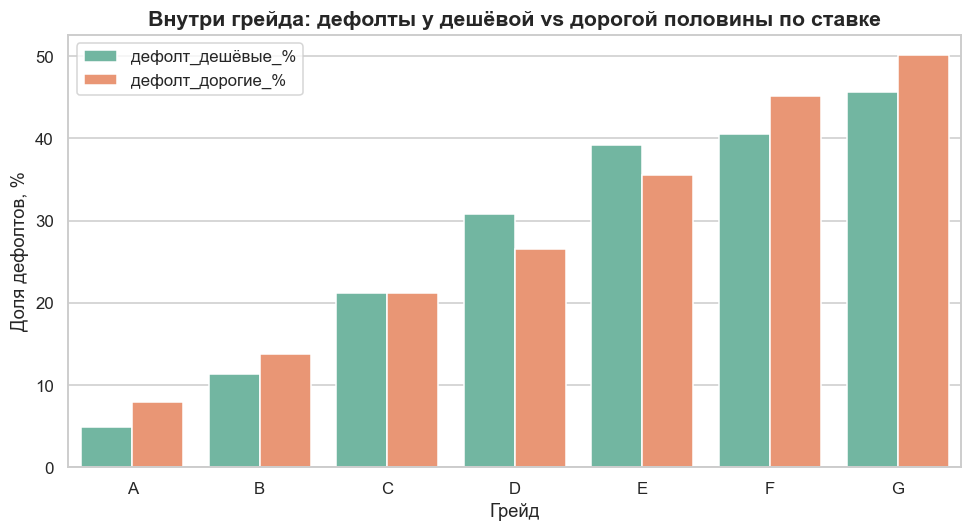

In [30]:
# визуализация H2: дефолт у "дешёвой" и "дорогой" половины внутри грейда
m = h2.melt(id_vars="грейд", value_vars=["дефолт_дешёвые_%", "дефолт_дорогие_%"],
            var_name="половина", value_name="дефолт_%")
plt.figure(figsize=(9, 5))
sns.barplot(data=m, x="грейд", y="дефолт_%", hue="половина", palette="Set2")
plt.title("Внутри грейда: дефолты у дешёвой vs дорогой половины по ставке")
plt.xlabel("Грейд"); plt.ylabel("Доля дефолтов, %"); plt.legend(title="")
plt.tight_layout(); plt.show()

**Вывод по H2.** Гипотеза **в чистом виде не подтвердилась**: эффект очень слабый и
неоднозначный. В грейдах A, B, C, F, G корреляция ставки с дефолтом слабо-положительная (дорогие
кредиты дефолтят чуть чаще), но в D и E она слабо-отрицательная; по модулю все корреляции близки
к нулю (|r| ≤ 0.07). Содержательный вывод: после фиксации грейда ставка почти не несёт
дополнительной информации о риске — грейд уже вобрал её в себя. Такой «маленький и неясный
эффект» — нормальный и честный результат проверки гипотезы.

### Гипотеза 3 (бонус). Платёжная нагрузка к доходу связана с дефолтом

Проверим новый признак `payment_to_income`: чем большую часть дохода съедает платёж, тем выше
риск дефолта. Тест: точечно-бисериальная корреляция + доля дефолтов по квартилям нагрузки.

Корреляция payment_to_income ↔ is_default: r = 0.130, p = 0.00e+00

Доля дефолтов по квартилям платёжной нагрузки:
pti_quartile
Q1 (низкая)    13.30
Q2             16.90
Q3             21.10
Q4 (высокая)   27.10


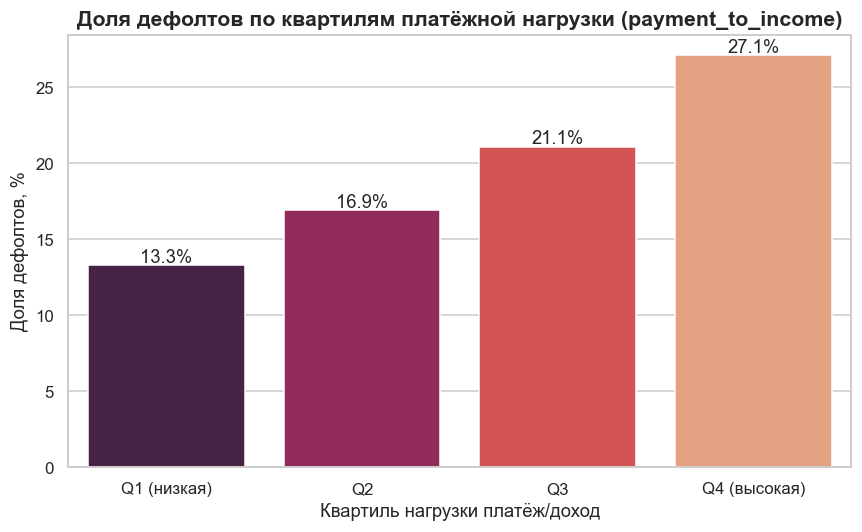

In [31]:
r, p = stats.pointbiserialr(data["is_default"], data["payment_to_income"])
print(f"Корреляция payment_to_income ↔ is_default: r = {r:.3f}, p = {p:.2e}")

data["pti_quartile"] = pd.qcut(data["payment_to_income"], 4,
                               labels=["Q1 (низкая)", "Q2", "Q3", "Q4 (высокая)"])
dr = (data.groupby("pti_quartile")["is_default"].mean() * 100).round(1)
print("\nДоля дефолтов по квартилям платёжной нагрузки:")
print(dr.to_string())

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=dr.index, y=dr.values, palette="rocket")
plt.title("Доля дефолтов по квартилям платёжной нагрузки (payment_to_income)")
plt.xlabel("Квартиль нагрузки платёж/доход"); plt.ylabel("Доля дефолтов, %")
for i, v in enumerate(dr.values):
    ax.text(i, v + 0.2, f"{v}%", ha="center")
plt.tight_layout(); plt.show()

**Вывод по H3.** Корреляция положительна и значима (p ≪ 0.05): доля дефолтов растёт от нижнего
квартиля платёжной нагрузки к верхнему. Гипотеза **подтвердилась** — заёмщики, у которых платёж
съедает большую долю дохода, чаще уходят в дефолт.

## 9. Выводы

1. **Грейд — рабочая мера риска.** Доля дефолтов почти монотонно растёт от A (~5–7%) к G
   (~35–40%), и ставка по грейдам растёт так же: платформа закладывает риск в цену кредита.
2. **Срок — самостоятельный фактор риска.** 60-месячные кредиты дефолтят чаще 36-месячных
   *внутри каждого грейда* (H1) — значимо в грейдах A–F; это не артефакт грейда.
3. **Ставка почти не добавляет информации сверх грейда** (H2): внутри одного грейда связь ставки
   с дефолтом близка к нулю и неоднозначна по знаку — грейд уже вобрал в себя риск-информацию.
4. **Платёжная нагрузка к доходу важна** (H3): чем большую долю дохода съедает платёж, тем выше
   риск дефолта.
5. **Что слабо влияет:** стаж работы почти не связан с дефолтом, а проверка дохода парадоксально
   не снижает риск — платформа тщательнее проверяет именно подозрительные заявки.

**Практический смысл.** Для оценки риска кредита ключевые сигналы — грейд/ставка, срок и
платёжная нагрузка; стаж и формальная проверка дохода добавляют мало. Анализ выполнен на чистых
данных Lending Club с использованием pandas, matplotlib/seaborn и статистических тестов scipy.